# ID1000 / Nucrypt attenuation measurement notebook

Use this notebook to run repeated ID1000 counter measurements while manually changing the Nucrypt source attenuation.

This version also calculates the **heralded second-order correlation at zero delay**, assuming:
- **Channel 3 = herald detector**
- **Channels 1 and 2 = outputs of the 50:50 splitter**

The heralded HBT estimator is

$$g_h^{(2)}(0)=\frac{R_{123}R_3}{R_{13}R_{23}},$$

where $R_3$ is the herald rate, $R_{13}$ and $R_{23}$ are the two heralded twofold rates, and $R_{123}$ is the threefold coincidence rate.

Workflow:
1. Set the path to your existing `coincidence_counters_acquisition.py` script.
2. Enter the measurement condition and attenuation manually.
3. Run one measurement per attenuation setting.
4. Analyse all CSV files in the condition folder.
5. Plot singles, coincidences, and heralded $g^{(2)}(0)$ versus attenuation.


In [1]:
# Install tqdm if needed:
#!pip install tqdm

from pathlib import Path
import subprocess
import sys
import time
import json
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

plt.rcParams["figure.figsize"] = (8, 5)

def safe_name(text):
    """Convert a text label into a safe folder/file name."""
    text = str(text).strip()
    text = re.sub(r"[^\w\s\-.]", "", text)
    text = re.sub(r"\s+", "_", text)
    return text if text else "measurement"


## 1. Configure paths and default acquisition parameters

In [2]:
# Path to your acquisition script.
# Change this to the local path on your experiment PC if needed.
SCRIPT_PATH = Path(r"C:\Users\Experiment\Documents\Python\VQ_Instruments\ID1000\coincidence_counters_acquisition.py")

# Main folder where all attenuation scans will be saved.
BASE_DATA_FOLDER = Path(r"C:\Users\Experiment\Documents\Python\VQ_Instruments\ID1000\ID_1000_data\attenuation_scans")

# ID1000 / Time Controller IP address
TC_ADDRESS = "169.254.224.106"

# Acquisition settings
ACQUISITION_INTERVAL_S = 2
N_min = 5
ACQUISITION_DURATION_S = N_min * 60

# Coincidence settings
COINCIDENCE_WINDOW_PS = 1000
COUNTERS_INTEGRATION_TIME_NS = 1000

# Columns to analyse
TIME_COLUMN = "time"
SINGLE_1_COLUMN = "input 1"
SINGLE_2_COLUMN = "input 2"
SINGLE_3_COLUMN = "input 3"       # herald detector
COINCIDENCE_COLUMN = "1/2"
COINCIDENCE_13_COLUMN = "1/3"    # detector 1 + herald
COINCIDENCE_23_COLUMN = "2/3"    # detector 2 + herald
TRIPLE_123_COLUMN = "1/2/3"      # detector 1 + detector 2 + herald
DETECTOR_EFFICIENCY = 0.15  
PUMP_REPETITION_RATE_HZ = 50e6  # Nucrypt source clock/pump rate, change if needed

BASE_DATA_FOLDER.mkdir(parents=True, exist_ok=True)

print("Base data folder:", BASE_DATA_FOLDER)
print("Measurement duration:", ACQUISITION_DURATION_S, "s")


Base data folder: C:\Users\Experiment\Documents\Python\VQ_Instruments\ID1000\ID_1000_data\attenuation_scans
Measurement duration: 300 s


## 2. Enter measurement condition

This condition name will be used as the folder name. Examples:
- `Nucrypt_CH44_CH24_DC_2us_window_2ns`
- `Nucrypt_CH44_CH24_pulsed_gate_3ns`
- `SPDC_alignment_test_filter_100GHz`


In [98]:
MEASUREMENT_CONDITION = "Nucrypt_CH25_CH43_DT_3us_eff_20_Freq_50MHz_2026_08_21"

condition_folder = BASE_DATA_FOLDER / safe_name(MEASUREMENT_CONDITION)
condition_folder.mkdir(parents=True, exist_ok=True)

log_folder = condition_folder / "logs"
log_folder.mkdir(parents=True, exist_ok=True)

print("Current condition folder:")
print(condition_folder)


Current condition folder:
C:\Users\Experiment\Documents\Python\VQ_Instruments\ID1000\ID_1000_data\attenuation_scans\Nucrypt_CH25_CH43_DT_3us_eff_20_Freq_50MHz_2026_08_21


## 3. Run one measurement at one manual attenuation setting

Before running this cell:
1. Set the Nucrypt attenuation manually.
2. Enter the attenuation value below.
3. Enter any note you want saved with the measurement.
4. Run the cell.

The progress bar estimates completion based on `ACQUISITION_DURATION_S`. The acquisition script performs the actual measurement and saves the CSV.


In [101]:
# ---- Enter these manually for each run ----
ATTENUATION_DB = -18.0
RUN_NOTE = "using CH25 as heralding"

In [102]:
timestamp = time.strftime("%Y%m%d_%H%M%S")

# Create a short unique run ID
run_id = timestamp

# Create a string suitable for filenames
attenuation_label = f"{ATTENUATION_DB:.2f}dB".replace(".", "p")

csv_filename = f"att_{attenuation_label}_run_{run_id}.csv"
log_filename = f"att_{attenuation_label}_run_{run_id}.log"
metadata_filename = f"att_{attenuation_label}_run_{run_id}.json"

csv_path = condition_folder / csv_filename
log_path = log_folder / log_filename
metadata_path = condition_folder / metadata_filename

cmd = [
    sys.executable,
    str(SCRIPT_PATH),
    "--address", str(TC_ADDRESS),
    "--interval", str(ACQUISITION_INTERVAL_S),
    "--duration", str(ACQUISITION_DURATION_S),
    "--file", str(csv_path),
    "--window", str(COINCIDENCE_WINDOW_PS),
    "--integration", str(COUNTERS_INTEGRATION_TIME_NS),
    "--log-path", str(log_path),
]

metadata = {
    "run_id": run_id,
    "measurement_condition": MEASUREMENT_CONDITION,
    "attenuation_dB": ATTENUATION_DB,
    "run_note": RUN_NOTE,
    "timestamp": timestamp,
    "csv_file": csv_filename,
    "log_file": log_filename,
    "tc_address": TC_ADDRESS,
    "acquisition_interval_s": ACQUISITION_INTERVAL_S,
    "acquisition_duration_s": ACQUISITION_DURATION_S,
    "coincidence_window_ps": COINCIDENCE_WINDOW_PS,
    "counters_integration_time_ns": COUNTERS_INTEGRATION_TIME_NS,
}

# Save individual metadata file
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

# -------------------------------------------------------------------
# Update master index file containing all attenuation measurements
# -------------------------------------------------------------------

index_file = condition_folder / "measurement_index.csv"

index_entry = pd.DataFrame([{
    "run_id": run_id,
    "timestamp": timestamp,
    "attenuation_dB": ATTENUATION_DB,
    "csv_file": csv_filename,
    "log_file": log_filename,
    "note": RUN_NOTE
}])

if index_file.exists():
    index_entry.to_csv(index_file, mode="a",
                       header=False, index=False)
else:
    index_entry.to_csv(index_file, index=False)

print("Running measurement:")
print(f"Run ID          : {run_id}")
print(f"Attenuation     : {ATTENUATION_DB} dB")
print(f"CSV file        : {csv_filename}")

process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

start_time = time.time()

with tqdm(total=ACQUISITION_DURATION_S,
          unit="s",
          desc=f"{ATTENUATION_DB:.2f} dB") as pbar:

    while process.poll() is None:
        elapsed = time.time() - start_time
        pbar.n = min(elapsed, ACQUISITION_DURATION_S)
        pbar.refresh()
        time.sleep(0.5)

    pbar.n = ACQUISITION_DURATION_S
    pbar.refresh()

output = process.stdout.read() if process.stdout else ""
return_code = process.returncode

print("\nFinished with return code:", return_code)

if output.strip():
    print("\nScript output:")
    print(output)

if return_code != 0:
    raise RuntimeError(
        "Acquisition script returned an error. "
        "Check the script output and log file."
    )

print("Saved:", csv_path)


Running measurement:
Run ID          : 20260821_125751
Attenuation     : -18.0 dB
CSV file        : att_-18p00dB_run_20260821_125751.csv


-18.00 dB:   0%|          | 0/300 [00:00<?, ?s/s]


Finished with return code: 0
Saved: C:\Users\Experiment\Documents\Python\VQ_Instruments\ID1000\ID_1000_data\attenuation_scans\Nucrypt_CH25_CH43_DT_3us_eff_20_Freq_50MHz_2026_08_21\att_-18p00dB_run_20260821_125751.csv


## 4. Read all saved files and calculate averages

This cell reads every CSV file in the selected condition folder and calculates the existing singles/coincidence metrics plus the heralded HBT quantities:
- $R_3$: channel-3 herald rate
- $R_{13}$: channel 1 / channel 3 coincidence rate
- $R_{23}$: channel 2 / channel 3 coincidence rate
- $R_{123}$: channel 1 / channel 2 / channel 3 threefold rate
- $g_h^{(2)}(0)=R_{123}R_3/(R_{13}R_{23})$

The CSV therefore needs to contain `input 3`, `1/3`, `2/3`, and `1/2/3` counters in addition to the original columns. If your ID1000 acquisition script uses different labels, change the column-name constants in Section 1.


In [88]:
def read_metadata_for_csv(csv_file):
    json_file = csv_file.with_suffix(".json")
    if json_file.exists():
        with open(json_file, "r") as f:
            return json.load(f)

    # Fallback: try to extract attenuation from filename, e.g. att_15p00dB
    match = re.search(r"att_([0-9]+p?[0-9]*)dB", csv_file.name)
    att = np.nan
    if match:
        att = float(match.group(1).replace("p", "."))

    return {
        "attenuation_dB": att,
        "measurement_condition": csv_file.parent.name,
        "run_note": "",
        "csv_path": str(csv_file),
    }


def read_counter_csv(csv_file):
    """Read ID1000 counter CSV. The script saves semicolon-separated files."""
    return pd.read_csv(csv_file, sep=";")


def summarise_counter_file(csv_file):
    meta = read_metadata_for_csv(csv_file)
    data = read_counter_csv(csv_file)

    required_columns = [
        TIME_COLUMN, SINGLE_1_COLUMN, SINGLE_2_COLUMN, SINGLE_3_COLUMN,
        COINCIDENCE_COLUMN, COINCIDENCE_13_COLUMN, COINCIDENCE_23_COLUMN,
        TRIPLE_123_COLUMN
    ]
    missing = [c for c in required_columns if c not in data.columns]
    if missing:
        raise ValueError(f"{csv_file.name} is missing columns: {missing}")

    for col in required_columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    summary = {
        "file": csv_file.name,
        "attenuation_dB": float(meta.get("attenuation_dB", np.nan)),
        "condition": meta.get("measurement_condition", csv_file.parent.name),
        "note": meta.get("run_note", ""),
        "n_points": len(data),
        "duration_s": data[TIME_COLUMN].max() - data[TIME_COLUMN].min(),
        "input1_mean": data[SINGLE_1_COLUMN].mean(),
        "input1_std": data[SINGLE_1_COLUMN].std(),
        "input2_mean": data[SINGLE_2_COLUMN].mean(),
        "input2_std": data[SINGLE_2_COLUMN].std(),
        "input3_mean": data[SINGLE_3_COLUMN].mean(),
        "input3_std": data[SINGLE_3_COLUMN].std(),
        "coinc_12_mean": data[COINCIDENCE_COLUMN].mean(),
        "coinc_12_std": data[COINCIDENCE_COLUMN].std(),
        "coinc_13_mean": data[COINCIDENCE_13_COLUMN].mean(),
        "coinc_13_std": data[COINCIDENCE_13_COLUMN].std(),
        "coinc_23_mean": data[COINCIDENCE_23_COLUMN].mean(),
        "coinc_23_std": data[COINCIDENCE_23_COLUMN].std(),
        "triple_123_mean": data[TRIPLE_123_COLUMN].mean(),
        "triple_123_std": data[TRIPLE_123_COLUMN].std(),
    }
    return summary


csv_files = sorted(condition_folder.glob("att_*_run_*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No acquisition CSV files found in {condition_folder}")

summary_rows = [summarise_counter_file(f) for f in csv_files]

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("attenuation_dB")
    .reset_index(drop=True)
)

summary_df



#DETECTOR_EFFICIENCY = 0.15  # 25%

# Accidentals estimate using measured singles and coincidence window
coincidence_window_s = COINCIDENCE_WINDOW_PS * 1e-12

summary_df["accidentals"] = (
    summary_df["input1_mean"] *
    summary_df["input3_mean"] *
    coincidence_window_s
)

summary_df["accidentals2"] = (
    summary_df["input2_mean"] *
    summary_df["input3_mean"] *
    coincidence_window_s
)

summary_df["CAR1"] = summary_df[ "coinc_13_mean"] / summary_df["accidentals"]

summary_df["CAR2"] = summary_df[ "coinc_23_mean"] / summary_df["accidentals2"]

# Heralded efficiencies
summary_df["efficiency_1_to_2_percent"] = (
    summary_df[ "coinc_13_mean"] / summary_df["input3_mean"]
) / DETECTOR_EFFICIENCY * 100

summary_df["efficiency_2_to_1_percent"] = (
    summary_df[ "coinc_23_mean"] / summary_df["input3_mean"]
) / DETECTOR_EFFICIENCY * 100


# ---------------------------------------------------------
# Pair probability per pump pulse
# ---------------------------------------------------------

#PUMP_REPETITION_RATE_HZ = 50e6  # Nucrypt source clock/pump rate, change if needed

summary_df["pair_probability"] = (
    summary_df[ "coinc_13_mean"]/
    (PUMP_REPETITION_RATE_HZ * DETECTOR_EFFICIENCY**2)
)

summary_df["pair_probability_percent"] = (
    summary_df["pair_probability"] * 100
)



# ---------------------------------------------------------
# Heralded second-order correlation at zero delay
# Channel 3 is the herald; channels 1 and 2 are the HBT arms.
#
#                 R_123 * R_3
# g_h^(2)(0) = -------------------
#                R_13 * R_23
# ---------------------------------------------------------

denominator = summary_df["coinc_13_mean"] * summary_df["coinc_23_mean"]

summary_df["g2_heralded_0"] = np.where(
    denominator > 0,
    (summary_df["triple_123_mean"] * summary_df["input3_mean"]) / denominator,
    np.nan
)

# A simple propagated uncertainty estimate using the measured run-to-run
# standard errors of the four rates. This is useful for plotting, but for
# very small threefold counts a Poisson/count-based confidence interval is
# preferable.
def fractional_sem(std, mean, n):
    sem = std / np.sqrt(n)
    return np.where(mean > 0, sem / mean, np.nan)

frac_R123 = fractional_sem(summary_df["triple_123_std"], summary_df["triple_123_mean"], summary_df["n_points"])
frac_R3   = fractional_sem(summary_df["input3_std"], summary_df["input3_mean"], summary_df["n_points"])
frac_R13  = fractional_sem(summary_df["coinc_13_std"], summary_df["coinc_13_mean"], summary_df["n_points"])
frac_R23  = fractional_sem(summary_df["coinc_23_std"], summary_df["coinc_23_mean"], summary_df["n_points"])

summary_df["g2_heralded_0_sem"] = summary_df["g2_heralded_0"] * np.sqrt(
    frac_R123**2 + frac_R3**2 + frac_R13**2 + frac_R23**2
)


print(summary_df.columns.tolist())
summary_df.head()




['file', 'attenuation_dB', 'condition', 'note', 'n_points', 'duration_s', 'input1_mean', 'input1_std', 'input2_mean', 'input2_std', 'input3_mean', 'input3_std', 'coinc_12_mean', 'coinc_12_std', 'coinc_13_mean', 'coinc_13_std', 'coinc_23_mean', 'coinc_23_std', 'triple_123_mean', 'triple_123_std', 'accidentals', 'accidentals2', 'CAR1', 'CAR2', 'efficiency_1_to_2_percent', 'efficiency_2_to_1_percent', 'pair_probability', 'pair_probability_percent', 'g2_heralded_0', 'g2_heralded_0_sem']


,file,attenuation_dB,condition,note,n_points,duration_s,input1_mean,input1_std,input2_mean,input2_std,...,accidentals,accidentals2,CAR1,CAR2,efficiency_1_to_2_percent,efficiency_2_to_1_percent,pair_probability,pair_probability_percent,g2_heralded_0,g2_heralded_0_sem
0,att_-20p00dB_run_20260821_113808.csv,-20.0,Nucrypt_CH24_CH44_DT_3us_eff_20_Freq_50MHz_V3,using CH24 as heralding,150,298.06,8348.513333,122.524548,22243.153333,247.909372,...,0.161330,0.429836,862.330617,302.611408,4.799452,4.487355,0.000124,0.012366,0.028477,0.014098
1,att_-20p00dB_run_20260821_113207.csv,-20.0,Nucrypt_CH24_CH44_DT_3us_eff_20_Freq_50MHz_V3,using CH24 as heralding,150,298.06,6008.733333,96.275239,20329.533333,312.228312,...,0.061746,0.208906,1001.526522,270.264727,4.011937,3.662904,0.000055,0.005497,0.000000,NaN
2,att_-18p00dB_run_20260821_113850.csv,-18.0,Nucrypt_CH24_CH44_DT_3us_eff_20_Freq_50MHz_V3,using CH24 as heralding,150,298.07,8337.100000,126.425177,22162.586667,278.811769,...,0.160848,0.427582,865.830153,303.130593,4.812342,4.478772,0.000124,0.012379,0.028502,0.014110
3,att_-16p00dB_run_20260821_114417.csv,-16.0,Nucrypt_CH24_CH44_DT_3us_eff_20_Freq_50MHz_V3,using CH24 as heralding,150,298.06,12794.233333,500.822885,24066.260000,3372.634605,...,0.466412,0.877332,645.337669,318.906093,5.504400,5.116585,0.000268,0.026755,0.049060,0.011246
4,att_-14p00dB_run_20260821_114949.csv,-14.0,Nucrypt_CH24_CH44_DT_3us_eff_20_Freq_50MHz_V3,using CH24 as heralding,150,298.09,22396.126667,329.385869,31115.946667,1182.887678,...,1.502061,2.086881,405.229791,272.824959,6.050385,5.659471,0.000541,0.054105,0.049027,0.007810


## 5. Plot averaged singles, coincidences, and heralded $g^{(2)}(0)$ versus attenuation


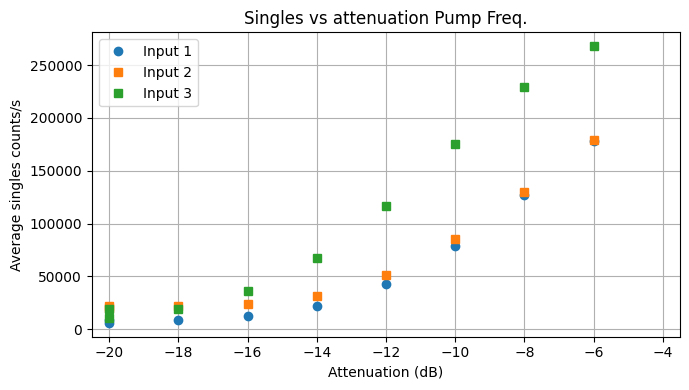

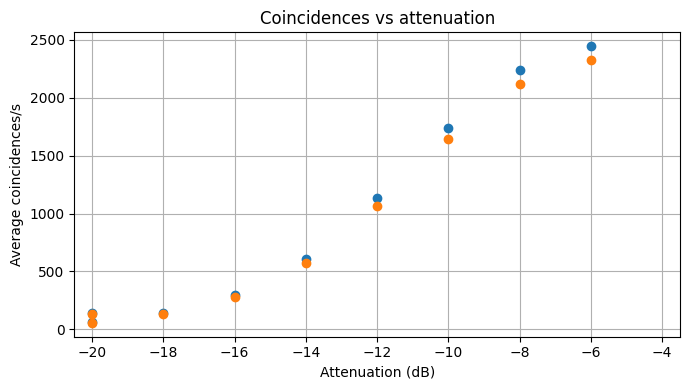

C:\Users\Experiment\AppData\Local\Temp\ipykernel_7616\3985882684.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


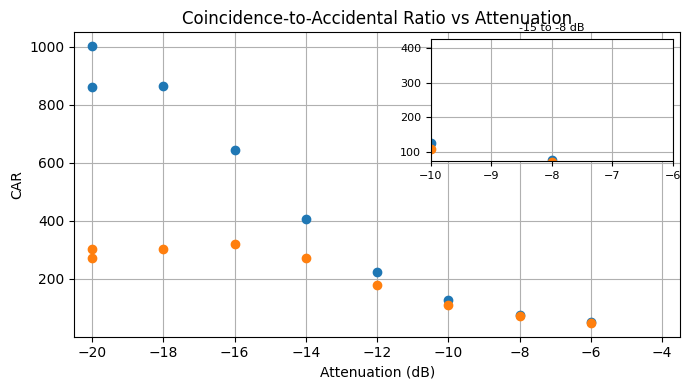

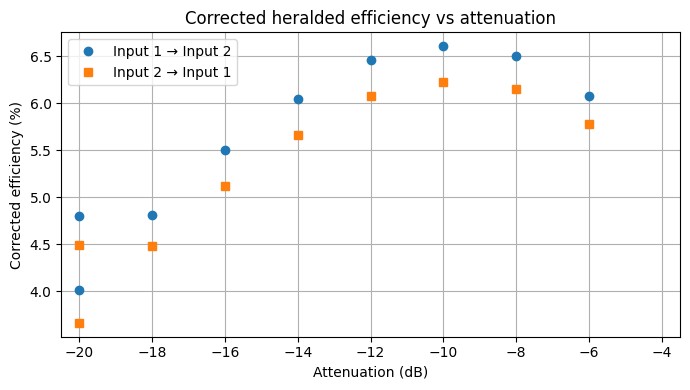

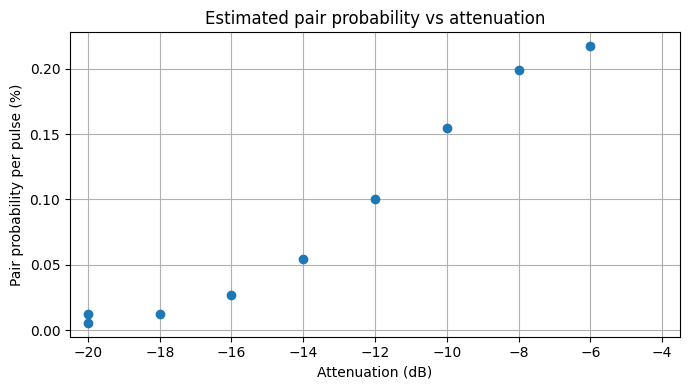

Plots saved in:
C:\Users\Experiment\Documents\Python\VQ_Instruments\ID1000\ID_1000_data\attenuation_scans\Nucrypt_CH24_CH44_DT_3us_eff_20_Freq_50MHz_V3\plots


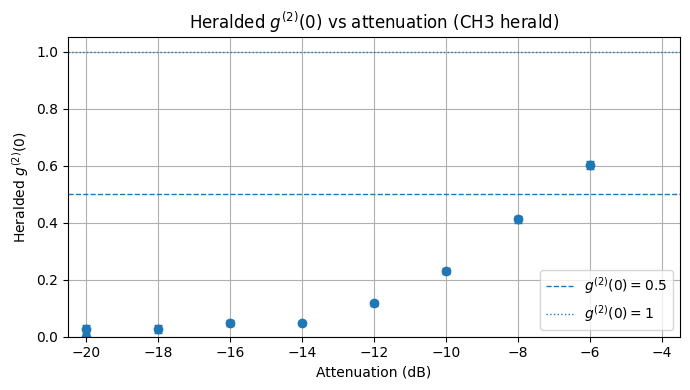

,attenuation_dB,input3_mean,coinc_13_mean,coinc_23_mean,triple_123_mean,g2_heralded_0,g2_heralded_0_sem
0,-20.0,19324.426667,139.120000,130.073333,0.026667,0.028477,0.014098
1,-20.0,10276.000000,61.840000,56.460000,0.000000,0.000000,NaN
2,-18.0,19292.986667,139.266667,129.613333,0.026667,0.028502,0.014110
3,-16.0,36454.873333,300.993333,279.786667,0.113333,0.049060,0.011246
4,-14.0,67067.906667,608.680000,569.353333,0.253333,0.049027,0.007810
5,-12.0,116618.360000,1130.033333,1063.333333,1.213333,0.117757,0.008455
6,-10.0,175509.726667,1739.880000,1639.040000,3.753333,0.230999,0.010141
7,-8.0,229498.673333,2237.246667,2118.980000,8.513333,0.412135,0.011612
8,-6.0,267944.440000,2444.313333,2322.420000,12.746667,0.601650,0.013741


In [89]:
# ---------------------------------------------------------
# Save all plots
# ---------------------------------------------------------

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plot_folder = condition_folder / "plots"
plot_folder.mkdir(exist_ok=True)

# ---------- 1. Singles plot ----------

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    summary_df["attenuation_dB"],
    summary_df["input1_mean"],
    marker="o",
    linestyle="none",
    label="Input 1"
)

ax.plot(
    summary_df["attenuation_dB"],
    summary_df["input2_mean"],
    marker="s",
    linestyle="none",
    label="Input 2"
)

ax.plot(
    summary_df["attenuation_dB"],
    summary_df["input3_mean"],
    marker="s",
    linestyle="none",
    label="Input 3"
)

ax.set_xlabel("Attenuation (dB)")
ax.set_ylabel("Average singles counts/s")
ax.set_title(f"Singles vs attenuation Pump Freq.")
ax.grid(True)
ax.set_xlim([-20.5,-3.5])
ax.legend()

fig.tight_layout()
fig.savefig(plot_folder / "singles_vs_attenuation.png", dpi=300)
fig.savefig(plot_folder / "singles_vs_attenuation.pdf")
plt.show()


# ---------- 2. Coincidences plot ----------

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    summary_df["attenuation_dB"],
    summary_df["coinc_13_mean"],
    #summary_df["coinc_23_mean"],
    marker="o",
    linestyle="none"
)

ax.plot(
    summary_df["attenuation_dB"],
    #summary_df["coinc_13_mean"],
    summary_df["coinc_23_mean"],
    marker="o",
    linestyle="none"
)

ax.set_xlabel("Attenuation (dB)")
ax.set_ylabel("Average coincidences/s")
ax.set_title("Coincidences vs attenuation")
ax.set_xlim([-20.5,-3.5])
ax.grid(True)

fig.tight_layout()
fig.savefig(plot_folder / "coincidences_vs_attenuation.png", dpi=300)
fig.savefig(plot_folder / "coincidences_vs_attenuation.pdf")
plt.show()


# ---------- 3. CAR plot with inset ----------

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    summary_df["attenuation_dB"],
    summary_df["CAR1"],
    marker="o",
    linestyle="none"
)

ax.plot(
    summary_df["attenuation_dB"],
    summary_df["CAR2"],
    marker="o",
    linestyle="none"
)

ax.set_xlabel("Attenuation (dB)")
ax.set_ylabel("CAR")
ax.set_title("Coincidence-to-Accidental Ratio vs Attenuation")
ax.set_xlim([-20.5,-3.5])
ax.grid(True)

axins = inset_axes(
    ax,
    width="40%",
    height="40%",
    loc="upper right"
)

# Use this range if attenuation is entered as negative dB values
mask = (
    (summary_df["attenuation_dB"] >= -15) &
    (summary_df["attenuation_dB"] <= -8)
)

inset_df = summary_df[mask]

axins.plot(
    inset_df["attenuation_dB"],
    inset_df["CAR1"],
    marker="o",
    linestyle="none"
)

axins.plot(
    inset_df["attenuation_dB"],
    inset_df["CAR2"],
    marker="o",
    linestyle="none"
)

axins.set_xlim(-10, -6)

if len(inset_df) > 0:
    ymin = 0.95 * inset_df["CAR1"].min()
    ymax = 1.05 * inset_df["CAR1"].max()

    if ymin == ymax:
        ymin *= 0.95
        ymax *= 1.05

    axins.set_ylim(ymin, ymax)

axins.grid(True)
axins.set_title("-15 to -8 dB", fontsize=8)
axins.tick_params(axis="both", labelsize=8)

fig.tight_layout()
fig.savefig(plot_folder / "CAR_vs_attenuation_with_inset.png", dpi=300)
fig.savefig(plot_folder / "CAR_vs_attenuation_with_inset.pdf")
plt.show()


# ---------- 4. Corrected efficiency plot ----------

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    summary_df["attenuation_dB"],
    summary_df["efficiency_1_to_2_percent"],
    marker="o",
    linestyle="none",
    label="Input 1 → Input 2"
)

ax.plot(
    summary_df["attenuation_dB"],
    summary_df["efficiency_2_to_1_percent"],
    marker="s",
    linestyle="none",
    label="Input 2 → Input 1"
)

ax.set_xlabel("Attenuation (dB)")
ax.set_ylabel("Corrected efficiency (%)")
ax.set_title("Corrected heralded efficiency vs attenuation")
ax.grid(True)
ax.set_xlim([-20.5,-3.5])
ax.legend()

fig.tight_layout()
fig.savefig(plot_folder / "corrected_efficiency_vs_attenuation.png", dpi=300)
fig.savefig(plot_folder / "corrected_efficiency_vs_attenuation.pdf")
plt.show()


# ---------- 5. Pair probability plot ----------

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    summary_df["attenuation_dB"],
    summary_df["pair_probability_percent"],
    marker="o",
    linestyle="none"
)

ax.set_xlabel("Attenuation (dB)")
ax.set_ylabel("Pair probability per pulse (%)")
ax.set_title("Estimated pair probability vs attenuation")
ax.set_xlim([-20.5,-3.5])
ax.grid(True)

fig.tight_layout()
fig.savefig(plot_folder / "pair_probability_vs_attenuation.png", dpi=300)
fig.savefig(plot_folder / "pair_probability_vs_attenuation.pdf")
plt.show()


print("Plots saved in:")
print(plot_folder)

# ---------- 6. Heralded g2(0) plot ----------

fig, ax = plt.subplots(figsize=(7, 4))

ax.errorbar(
    summary_df["attenuation_dB"],
    summary_df["g2_heralded_0"],
    yerr=summary_df["g2_heralded_0_sem"],
    marker="o",
    linestyle="none",
    capsize=3
)

ax.axhline(0.5, linestyle="--", linewidth=1, label=r"$g^{(2)}(0)=0.5$")
ax.axhline(1.0, linestyle=":", linewidth=1, label=r"$g^{(2)}(0)=1$")
ax.set_xlabel("Attenuation (dB)")
ax.set_ylabel(r"Heralded $g^{(2)}(0)$")
ax.set_title(r"Heralded $g^{(2)}(0)$ vs attenuation (CH3 herald)")
ax.set_xlim([-20.5, -3.5])
ax.set_ylim(bottom=0)
ax.grid(True)
ax.legend()

fig.tight_layout()
fig.savefig(plot_folder / "heralded_g2_0_vs_attenuation.png", dpi=300)
fig.savefig(plot_folder / "heralded_g2_0_vs_attenuation.pdf")
plt.show()

# Compact table of the quantities entering the g2 calculation
display_columns = [
    "attenuation_dB",
    "input3_mean",
    "coinc_13_mean",
    "coinc_23_mean",
    "triple_123_mean",
    "g2_heralded_0",
    "g2_heralded_0_sem",
]

display(summary_df[display_columns])


## 6. Analyse an existing output CSV quickly

In [32]:
EXISTING_CSV = Path(r"att_-6p00dB_run_20260731_112357.csv")

if EXISTING_CSV.exists():
    data = read_counter_csv(EXISTING_CSV)
    display(data.head())

    print("Columns:", list(data.columns))
    print()
    print("Averages:")
    quick_cols = [
        SINGLE_1_COLUMN, SINGLE_2_COLUMN, SINGLE_3_COLUMN,
        COINCIDENCE_13_COLUMN, COINCIDENCE_23_COLUMN, TRIPLE_123_COLUMN
    ]
    means = data[quick_cols].apply(pd.to_numeric, errors="coerce").mean()
    print(means)

    if means[COINCIDENCE_13_COLUMN] > 0 and means[COINCIDENCE_23_COLUMN] > 0:
        g2_quick = (
            means[TRIPLE_123_COLUMN] * means[SINGLE_3_COLUMN] /
            (means[COINCIDENCE_13_COLUMN] * means[COINCIDENCE_23_COLUMN])
        )
        print(f"\nHeralded g2(0), CH3 herald: {g2_quick:.4f}")
    else:
        print("\nCannot calculate heralded g2(0): one of the heralded twofold rates is zero.")
else:
    print("File not found. Update EXISTING_CSV to point to your CSV file.")


File not found. Update EXISTING_CSV to point to your CSV file.
